<a href="https://colab.research.google.com/github/camendozac/pruebaPython/blob/main/AprendizajeRepresentacion.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Dataset cargado: 1288 imágenes de 50x37 píxeles (1850 dimensiones por foto).


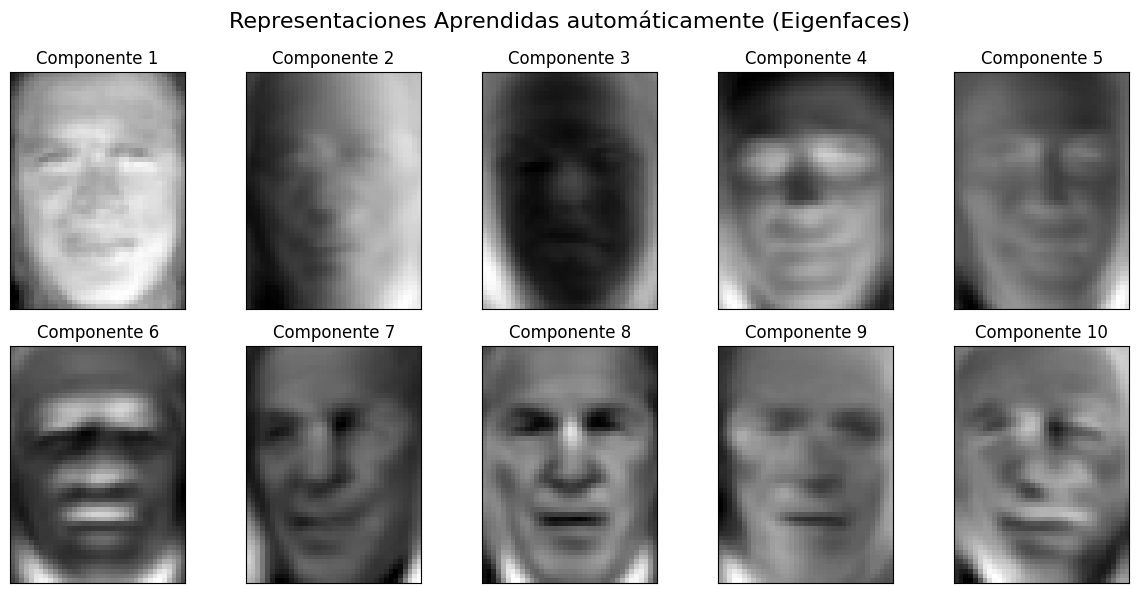

In [ ]:
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_lfw_people
from sklearn.decomposition import PCA

# 1. Cargar el dataset de rostros en blanco y negro (LFW)
# Tomamos fotos que tengan al menos 70 imágenes por persona para el ejemplo
rostros = fetch_lfw_people(min_faces_per_person=70, resize=0.4)
n_muestras, alto, ancho = rostros.images.shape

# Los datos se configuran como una matriz donde cada fila es una imagen aplanada
X = rostros.data
n_caracteristicas = X.shape[1]

print(f"Dataset cargado: {n_muestras} imágenes de {alto}x{ancho} píxeles ({n_caracteristicas} dimensiones por foto).")

# 2. Aplicar Aprendizaje por Representación usando PCA
# Reducimos las miles de dimensiones de píxeles a solo 50 componentes principales (representaciones)
n_componentes = 50
pca = PCA(n_components=n_componentes, whiten=True).fit(X)

# Extraemos las "Eigenfaces" (las bases de datos vectoriales aprendidas)
eigenfaces = pca.components_.reshape((n_componentes, alto, ancho))

# 3. Graficar las representaciones aprendidas (Eigenfaces)
# Estas imágenes muestran las características abstractas que el algoritmo detectó como más importantes
fig, mapas = plt.subplots(2, 5, figsize=(12, 6), subplot_kw={'xticks': [], 'yticks': []})
fig.suptitle("Representaciones Aprendidas automáticamente (Eigenfaces)", fontsize=16)

for i, ax in enumerate(mapas.flat):
    ax.imshow(eigenfaces[i], cmap='gray')
    ax.set_title(f"Componente {i+1}")

plt.tight_layout()
plt.show()


Cargando imágenes de rostros...
Número de imágenes: 1288
Tamaño de cada imagen: 50x37 píxeles (1850 píxeles en total)

Extrayendo las 150 mejores representaciones (Eigenfaces)...

Mostrando las representaciones visuales extraídas por el algoritmo...


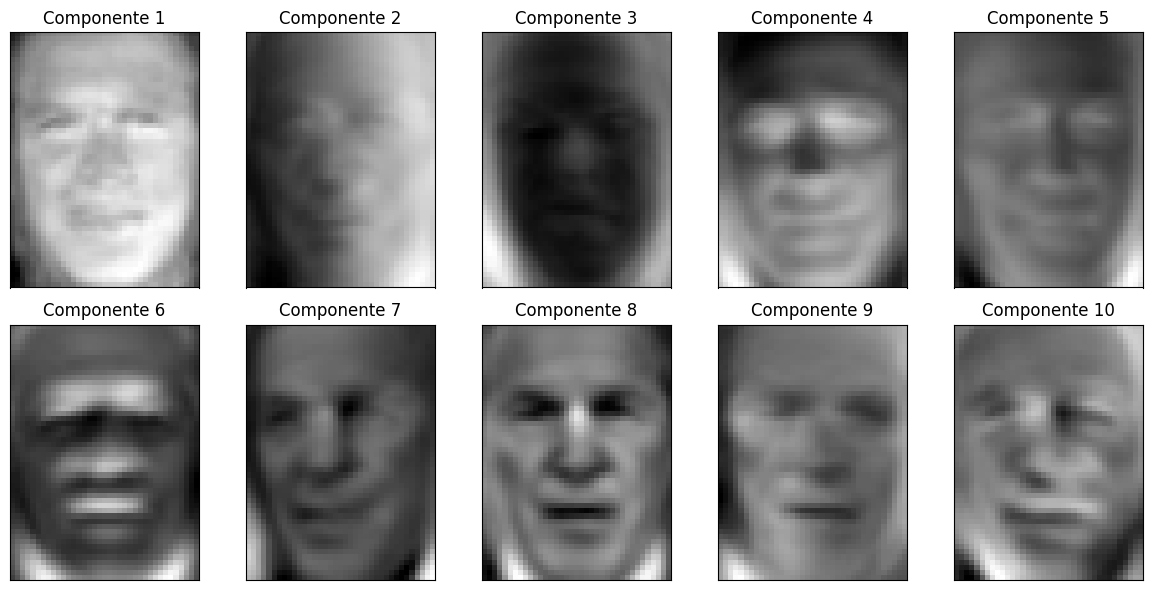


--- Ejemplo de transformación ---
Píxeles originales del primer rostro (primeros 5): [0.9973857  0.99607843 0.9921568  0.96601313 0.75816995] ...
Nueva representación del mismo rostro (primeros 5 valores numéricos): [ 0.45664442 -0.19516718 -0.31042144 -0.0942851   0.82487404] ...


In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.datasets import fetch_lfw_people
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split

# 1. Cargar el dataset de rostros en blanco y negro (LFW)
print("Cargando imágenes de rostros...")
rostros = fetch_lfw_people(min_faces_per_person=70, resize=0.4, color=False)
n_muestras, alto, ancho = rostros.images.shape

# Los datos brutos son una matriz de píxeles estirada en un vector
X = rostros.data
n_caracteristicas = X.shape[1]
y = rostros.target

print(f"Número de imágenes: {n_muestras}")
print(f"Tamaño de cada imagen: {alto}x{ancho} píxeles ({n_caracteristicas} píxeles en total)")

# 2. Aplicar Aprendizaje por Representación usando PCA
# Reduciremos de ~1850 píxeles a solo 50 componentes representativos
n_componentes = 50
print(f"\nExtrayendo las {n_componentes} mejores representaciones (Eigenfaces)...")
pca = PCA(n_components=n_componentes, whiten=True, random_state=42).fit(X)

# 3. Transformar los datos brutos a su nueva representación compacta
# Ahora cada rostro se define por solo 50 números en lugar de 1850 píxeles
X_representado = pca.transform(X)

# 4. Visualizar las representaciones aprendidas (Eigenfaces)
# Estas son las características abstractas (bordes, sombras, formas) que el modelo descubrió
print("\nMostrando las representaciones visuales extraídas por el algoritmo...")
fig, axes = plt.subplots(2, 5, figsize=(12, 6),
                         subplot_kw={'xticks':[], 'yticks':[]})

for i, ax in enumerate(axes.flat):
    # Reconstruir la forma de la imagen para poder graficar el componente
    componente_visual = pca.components_[i].reshape(alto, ancho)
    ax.imshow(componente_visual, cmap='gray')
    ax.set_title(f"Componente {i+1}")

plt.tight_layout()
plt.show()

# 5. Ejemplo de cómo se ve un rostro en su nueva representación simplificada
print("\n--- Ejemplo de transformación ---")
print(f"Píxeles originales del primer rostro (primeros 5): {X[0][:5]} ...")
print(f"Nueva representación del mismo rostro (primeros 5 valores numéricos): {X_representado[0][:5]} ...")

In [ ]:
!pip install opencv-contrib-python numpy



In [ ]:
!pip install opencv-contrib-python

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.2/79.2 MB 6.4 MB/s eta 0:00:00


In [6]:
# Simula reconocimiento de imagenes
import cv2
import numpy as np

# 1. Crear datos de simulación (Reemplaza esto con tus imágenes reales)
# Las imágenes DEBEN tener estrictamente el mismo tamaño (ej. 100x100)
img1 = np.random.randint(0, 255, (100, 100), dtype=np.uint8)
img2 = np.random.randint(0, 255, (100, 100), dtype=np.uint8)

# Lista de imágenes de entrenamiento y sus etiquetas numéricas (IDs)
rostros_entrenamiento = [img1, img2]
etiquetas = np.array([0, 1])  # 0 = Persona A, 1 = Persona B

# 2. Inicializar el reconocedor de Eigenfaces
# Opcional: puedes pasar el número de componentes (ej. cv2.face.EigenFaceRecognizer_create(num_components=10))
reconocedor = cv2.face.EigenFaceRecognizer_create()

# 3. Entrenar el modelo
print("Entrenando el modelo de Eigenfaces...")
reconocedor.train(rostros_entrenamiento, etiquetas)
print("¡Entrenamiento completado!")

# 4. Simular una imagen de prueba (Nueva foto de la Persona A con ruido)
imagen_prueba = img1.copy()
cv2.randn(imagen_prueba, 0, 10) # Añade un poco de ruido aleatorio

# 5. Realizar la predicción
# 'etiqueta_predicha' devuelve el ID, 'confianza' es la distancia Euclidiana (menor es mejor)
etiqueta_predicha, confianza = reconocedor.predict(imagen_prueba)

print(# Resumen del resultado
    f"\nRostro reconocido como ID: {etiqueta_predicha}"
    f"\nNivel de confianza (distancia): {confianza:.2f}"
)

Entrenando el modelo de Eigenfaces...
¡Entrenamiento completado!

Rostro reconocido como ID: 1
Nivel de confianza (distancia): 5168.04


In [4]:
# Reconocimiento de rostro
#!pip install opencv-contrib-python

import cv2
import numpy as np

# ==========================================
# 1. SIMULACIÓN DE ENTRENAMIENTO (Sustituir por tus datos reales)
# ==========================================
# Creamos 2 imágenes artificiales de 100x100
rostro_persona_0 = np.random.randint(0, 255, (100, 100), dtype=np.uint8)
rostro_persona_1 = np.random.randint(0, 255, (100, 100), dtype=np.uint8)

rostros_entrenamiento = [rostro_persona_0, rostro_persona_1]
etiquetas = np.array([0, 1])

# Diccionario para mapear IDs numéricos a nombres reales
nombres = {0: "Persona A", 1: "Persona B"}

# Crear y entrenar el reconocedor
reconocedor = cv2.face.EigenFaceRecognizer_create()
reconocedor.train(rostros_entrenamiento, etiquetas)

# ==========================================
# 2. CONFIGURACIÓN DE LA CÁMARA Y DETECTOR
# ==========================================
# Cargar el detector de rostros preentrenado de OpenCV
detector_rostros = cv2.CascadeClassifier(cv2.data.haarcascades + 'haarcascade_frontalface_default.xml')

# Iniciar la captura de video (0 suele ser la cámara integrada)
camara = cv2.VideoCapture(0)

print("Presiona 'q' para salir del video.")

while True:
    # Capturar cuadro por cuadro
    ret, cuadro = camara.read()
    if not ret:
        print("Error: No se pudo acceder a la cámara.")
        break

    # Convertir el cuadro a escala de grises (necesario para Haar y Eigenfaces)
    gris = cv2.cvtColor(cuadro, cv2.COLOR_BGR2GRAY)

    # Detectar rostros en la pantalla
    rostros_detectados = detector_rostros.detectMultiScale(gris, scaleFactor=1.3, minNeighbors=5)

    for (x, y, w, h) in rostros_detectados:
        # 1. Recortar la región del rostro (ROI)
        rostro_recortado = gris[y:y+h, x:x+w]

        # 2. Redimensionar exactamente al tamaño con el que se entrenó (100x100)
        rostro_listo = cv2.resize(rostro_recortado, (100, 100))

        # 3. Predecir la identidad
        id_predicho, confianza = reconocedor.predict(rostro_listo)

        # 4. Definir el nombre según el resultado (Umbral de confianza opcional)
        # Nota: En Eigenfaces, una confianza menor a ~5000 suele ser buena (varía según tus datos)
        if confianza < 8000:
            nombre_usuario = nombres.get(id_predicho, "Desconocido")
        else:
            nombre_usuario = "Desconocido"

        # 5. Dibujar un rectángulo y el nombre en la pantalla
        cv2.rectangle(cuadro, (x, y), (x+w, y+h), (0, 255, 0), 2)
        texto = f"{nombre_usuario} ({int(confianza)})"
        cv2.putText(cuadro, texto, (x, y-10), cv2.FONT_HERSHEY_SIMPLEX, 0.8, (0, 255, 0), 2)

    # Mostrar el video resultante en una ventana
    cv2.imshow('Reconocimiento Facial - Eigenfaces', cuadro)

    # Romper el bucle si se presiona la tecla 'q'
    if cv2.waitKey(1) & 0xFF == ord('q'):
        break

# Liberar la cámara y cerrar las ventanas
camara.release()
cv2.destroyAllWindows()

Presiona 'q' para salir del video.
Error: No se pudo acceder a la cámara.


In [6]:
print(dir(cv2.face))

['__doc__', '__file__', '__loader__', '__name__', '__package__', '__path__', '__spec__']


In [2]:
!pip uninstall -y opencv-python opencv-contrib-python opencv-python-headless
!pip install opencv-contrib-python


Found existing installation: opencv-python 4.13.0.92
Uninstalling opencv-python-4.13.0.92:
  Successfully uninstalled opencv-python-4.13.0.92
Found existing installation: opencv-contrib-python 4.13.0.92
Uninstalling opencv-contrib-python-4.13.0.92:
  Successfully uninstalled opencv-contrib-python-4.13.0.92
Found existing installation: opencv-python-headless 4.13.0.92
Uninstalling opencv-python-headless-4.13.0.92:
  Successfully uninstalled opencv-python-headless-4.13.0.92
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.2/79.2 MB 8.2 MB/s eta 0:00:00
